In [1]:
!pip install plotly kaleido seaborn pandas matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.0/69.0 kB 279.2 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.3/49.3 kB 42.9 kB/s eta 0:00:00


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded!")

Libraries loaded!


In [3]:
URL = 'https://raw.githubusercontent.com/owid/covid-19-data/master/public/data/owid-covid-data.csv'

print("Downloading... please wait")
df = pd.read_csv(URL)
print(f"Dataset loaded: {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head()

Downloading... please wait
Dataset loaded: 429,435 rows x 67 columns


,iso_code,continent,location,date,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,...,male_smokers,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,human_development_index,population,excess_mortality_cumulative_absolute,excess_mortality_cumulative,excess_mortality,excess_mortality_cumulative_per_million
0,AFG,Asia,Afghanistan,2020-01-05,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN
1,AFG,Asia,Afghanistan,2020-01-06,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN
2,AFG,Asia,Afghanistan,2020-01-07,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN
3,AFG,Asia,Afghanistan,2020-01-08,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN
4,AFG,Asia,Afghanistan,2020-01-09,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN


In [4]:
print("=== Column names ===")
print(df.columns.tolist())

print("\n=== Date range ===")
print("From:", df['date'].min(), "To:", df['date'].max())

print("\n=== Countries in dataset ===")
print(df['location'].nunique(), "countries/regions")

print("\n=== Missing values (top 5) ===")
print(df.isnull().sum().sort_values(ascending=False).head(5))

=== Column names ===
['iso_code', 'continent', 'location', 'date', 'total_cases', 'new_cases', 'new_cases_smoothed', 'total_deaths', 'new_deaths', 'new_deaths_smoothed', 'total_cases_per_million', 'new_cases_per_million', 'new_cases_smoothed_per_million', 'total_deaths_per_million', 'new_deaths_per_million', 'new_deaths_smoothed_per_million', 'reproduction_rate', 'icu_patients', 'icu_patients_per_million', 'hosp_patients', 'hosp_patients_per_million', 'weekly_icu_admissions', 'weekly_icu_admissions_per_million', 'weekly_hosp_admissions', 'weekly_hosp_admissions_per_million', 'total_tests', 'new_tests', 'total_tests_per_thousand', 'new_tests_per_thousand', 'new_tests_smoothed', 'new_tests_smoothed_per_thousand', 'positive_rate', 'tests_per_case', 'tests_units', 'total_vaccinations', 'people_vaccinated', 'people_fully_vaccinated', 'total_boosters', 'new_vaccinations', 'new_vaccinations_smoothed', 'total_vaccinations_per_hundred', 'people_vaccinated_per_hundred', 'people_fully_vaccinated_

In [5]:
df['date'] = pd.to_datetime(df['date'])

countries = ['India', 'United States', 'Brazil', 'United Kingdom']
df_f = df[df['location'].isin(countries)].copy()

df_f['new_cases'] = df_f['new_cases'].fillna(0)
df_f['new_deaths'] = df_f['new_deaths'].fillna(0)

df_f['death_rate'] = (df_f['total_deaths'] / df_f['total_cases'] * 100).round(2)
df_f['death_rate'] = df_f['death_rate'].fillna(0)

df_f['new_cases_7d'] = df_f.groupby('location')['new_cases'].transform(
    lambda x: x.rolling(7, min_periods=1).mean().round(0)
)

print("Data cleaned!")
print(f"Rows: {df_f.shape[0]:,} | Countries: {df_f['location'].nunique()}")
df_f[['date','location','new_cases','death_rate']].head(6)

Data cleaned!
Rows: 6,704 | Countries: 4


,date,location,new_cases,death_rate
50234,2020-01-05,Brazil,0.0,0.0
50235,2020-01-06,Brazil,0.0,0.0
50236,2020-01-07,Brazil,0.0,0.0
50237,2020-01-08,Brazil,0.0,0.0
50238,2020-01-09,Brazil,0.0,0.0
50239,2020-01-10,Brazil,0.0,0.0


In [6]:
import plotly.express as px

fig = px.line(
    df_f, x='date', y='new_cases_7d', color='location',
    title='Daily New COVID-19 Cases (7-day average)',
    labels={'new_cases_7d': 'New Cases', 'date': 'Date', 'location': 'Country'},
    template='plotly_white'
)
fig.show()
print("Chart done!")

Chart done!


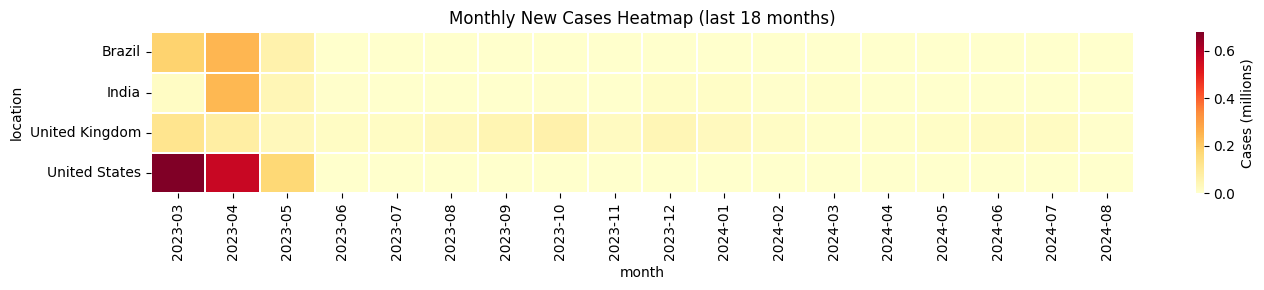

In [7]:
import numpy as np

deaths = df_f.groupby('location')['total_deaths'].max().reset_index()
deaths = deaths.sort_values('total_deaths')

fig2 = px.bar(deaths, x='total_deaths', y='location', orientation='h',
              title='Total COVID-19 Deaths by Country',
              labels={'total_deaths':'Total Deaths','location':''},
              template='plotly_white', color='location',
              color_discrete_sequence=px.colors.qualitative.Set2)
fig2.show()

df_f['month'] = df_f['date'].dt.to_period('M').astype(str)
monthly = df_f.groupby(['location','month'])['new_cases'].sum().reset_index()
pivot = monthly.pivot(index='location', columns='month', values='new_cases')
pivot = pivot.iloc[:, -18:]

plt.figure(figsize=(14, 3))
sns.heatmap(pivot/1e6, cmap='YlOrRd', linewidths=0.3,
            cbar_kws={'label':'Cases (millions)'})
plt.title('Monthly New Cases Heatmap (last 18 months)')
plt.tight_layout()
plt.show()